<a href="https://colab.research.google.com/github/amarchini5339/AAI-511-group7/blob/fix-dataset/notebooks/Notebook-Team_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment Setup and Library Imports

Set up Colab environment and import preliminary required packages

Set up Google Colab

In [36]:
from google.colab import drive
drive.mount('/content/drive')

# Path to extracted features (adjust as necessary)
DATA_PATH = "/content/drive/MyDrive/AAI-511-group7-main/notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Install necessary libraries (through Google Colab)

In [ ]:
%pip install -q pretty_midi numpy tensorflow scikit-learn matplotlib seaborn tqdm

Import required Python libraries

In [38]:
import pretty_midi
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# LSTM for Composer Classification

## Feature Extraction

### MIDI Dataset Preprocessing for LSTM

This code cell implements a data preprocessing pipeline for a MIDI dataset, preparing it for an LSTM model. It defines a function to extract features (pitch, velocity, duration, time since last note) from MIDI files. It then recursively scans composer folders, splits files into train, dev, and test sets per composer, extracts features for allowed composers, normalizes sequence lengths by truncating or padding, and assigns integer labels. Finally, it converts the processed features and labels into NumPy arrays for each data split.

**Key Tasks:**

- **Feature Extraction:** Extracts pitch, velocity, duration, and time since last note for each note in a MIDI file.
- **Sequence Normalization:** Truncates or pads note sequences to a fixed length.
- **Data Organization:** Maps composer names to integer labels and organizes features and labels by data split.
- **Data Consolidation:** Converts lists of features and labels into NumPy arrays.
- **Per-Composer Splitting:** Splits each composer's files into train, dev, and test sets using fixed ratios, handling edge cases for small classes.
- **Validation:** Prints the shapes of the prepared data and the label-to-composer mapping, indicating the dataset is ready for model training.

In [39]:
DATA_DIR = "/content/drive/MyDrive/AAI-511-group7-main/Composer_Dataset"#../Composer_Dataset/NN_midi_files_extended"#"/content/drive/MyDrive/AAI-511-group7-main/Composer_Dataset"
SETS = ['train', 'dev', 'test']
FIXED_SEQUENCE_LENGTH = 5000  # truncate or pad to this many notes
ALLOWED_COMPOSERS = {'bach', 'beethoven', 'chopin', 'mozart'} # specified in project requirements

def extract_lstm_features(midi_path, max_length=FIXED_SEQUENCE_LENGTH):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        notes = []
        for inst in midi.instruments:
            if inst.is_drum:
                continue
            notes.extend(inst.notes)
        if not notes:
            return None  # skip empty or drum-only files

        notes.sort(key=lambda n: n.start)
        sequence = []
        prev_start = 0.0
        for note in notes:
            pitch = note.pitch
            velocity = note.velocity
            duration = note.end - note.start
            time_since_last = note.start - prev_start
            sequence.append([pitch, velocity, duration, time_since_last])
            prev_start = note.start

        # Zero-padding instead of repetition
        if len(sequence) >= max_length:
            sequence = sequence[:max_length]
        else:
            pad_length = max_length - len(sequence)
            padding = [[0.0, 0.0, 0.0, 0.0]] * pad_length
            sequence.extend(padding)

        return np.array(sequence, dtype=np.float32)

    except Exception as e:
        print(f"Failed to process {midi_path}: {e}")
        return None

MIDI_EXTS = {".mid", ".midi", ".MID", ".MIDI"}
RNG_SEED = 42
SPLIT_RATIOS = {"train": 0.70, "dev": 0.15, "test": 0.15}

# --- Helpers ---
def iter_mid_paths(root_dir):
    """Yield .mid/.midi files recursively under root_dir."""
    for dirpath, _, filenames in os.walk(root_dir):
        for fn in filenames:
            _, ext = os.path.splitext(fn)
            if ext in MIDI_EXTS:
                yield os.path.join(dirpath, fn)

def safe_stack(lst, split_name):
    if len(lst) == 0:
        raise ValueError(f"No data collected for split '{split_name}'. "
                         f"Check your paths/filters.")
    return np.stack(lst)

# --- Build splits from composer folders (no train/dev/test dirs) ---
rng = np.random.RandomState(RNG_SEED)

# Stable label mapping (alphabetical over allowed set)
composer_to_idx = {c: i for i, c in enumerate(sorted(ALLOWED_COMPOSERS))}

# Collect all file paths per composer (recursive)
files_by_composer = {}
for composer_name in os.listdir(DATA_DIR):
    cname = composer_name.lower()
    if cname not in ALLOWED_COMPOSERS:
        continue
    cpath = os.path.join(DATA_DIR, composer_name)
    if not os.path.isdir(cpath):
        continue
    midi_files = list(iter_mid_paths(cpath))
    if midi_files:
        files_by_composer[cname] = midi_files

if not files_by_composer:
    raise ValueError("No MIDI files found. Check DATA_DIR and folder structure.")

# Prepare containers
X = {'train': [], 'dev': [], 'test': []}
y = {'train': [], 'dev': [], 'test': []}

def split_counts(n, train_ratio, dev_ratio):
    """Compute per-composer counts with sane rounding and edge-case handling."""
    if n <= 2:
        # tiny classes: put at least 1 in train, remainder in test
        train_n = 1 if n >= 1 else 0
        dev_n = 0
        test_n = max(0, n - train_n)
        return train_n, dev_n, test_n
    train_n = int(round(n * train_ratio))
    dev_n = int(round(n * dev_ratio))
    # Ensure at least 1 in train if any exist
    if train_n == 0 and n > 0:
        train_n = 1
    # Fix rounding overflow/underflow
    if train_n + dev_n > n - 1:  # leave at least 1 for test if possible
        overflow = train_n + dev_n - (n - 1)
        # trim dev first, then train
        take_from_dev = min(dev_n, overflow)
        dev_n -= take_from_dev
        overflow -= take_from_dev
        if overflow > 0:
            train_n = max(1, train_n - overflow)
    test_n = n - train_n - dev_n
    return train_n, dev_n, test_n

# Do per-composer splits, then preprocess each file
for cname, paths in files_by_composer.items():
    label = composer_to_idx[cname]
    paths = np.array(paths)
    perm = rng.permutation(len(paths))
    paths = paths[perm]

    t_ratio = SPLIT_RATIOS['train']
    d_ratio = SPLIT_RATIOS['dev']
    train_n, dev_n, test_n = split_counts(len(paths), t_ratio, d_ratio)

    train_paths = paths[:train_n]
    dev_paths   = paths[train_n:train_n+dev_n]
    test_paths  = paths[train_n+dev_n:]

    for split, split_paths in [('train', train_paths), ('dev', dev_paths), ('test', test_paths)]:
        print(f"Processing {split.upper()} for {cname} ({len(split_paths)} files)...")
        for midi_path in tqdm(split_paths, desc=f"{split}/{cname}", leave=False):
            features = extract_lstm_features(midi_path)
            if features is not None:
                X[split].append(features)
                y[split].append(label)

# Convert to numpy arrays
for split in ['train', 'dev', 'test']:
    X[split] = safe_stack(X[split], split)
    y[split] = np.array(y[split], dtype=np.int64)
    print(f"{split}: {X[split].shape}, labels: {y[split].shape}")

print("Composer to index mapping (stable order):", composer_to_idx)

Processing TRAIN for mozart (180 files)...


train/mozart:  14%|█▍        | 26/180 [00:08<00:35,  4.30it/s]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/mozart:  37%|███▋      | 66/180 [00:18<00:36,  3.11it/s]

Failed to process /content/drive/MyDrive/AAI-511-group7-main/Composer_Dataset/Mozart/Piano Sonatas/Nueva carpeta/K281 Piano Sonata n03 3mov.mid: Could not decode key with 2 flats and mode 2


Processing DEV for mozart (39 files)...


Processing TEST for mozart (38 files)...


...

Processing TEST for beethoven (32 files)...


Processing TRAIN for bach (717 files)...


Processing DEV for bach (154 files)...


Processing TEST for bach (153 files)...


train: (1140, 5000, 4), labels: (1140,)
dev: (244, 5000, 4), labels: (244,)
test: (244, 5000, 4), labels: (244,)
Composer to index mapping (stable order): {'bach': 0, 'beethoven': 1, 'chopin': 2, 'mozart': 3}


In [40]:
# Feature scaling

# Columns: [pitch, velocity, duration, time_since_last]
# log1p the last 2 columns to reduce skew
# train_features = X['train'].copy()

# # 1) Log scale duration and time_since_last
# for split in ['train', 'dev', 'test']:
#     X[split][:, :, 2] = np.log1p(X[split][:, :, 2])  # duration
#     X[split][:, :, 3] = np.log1p(X[split][:, :, 3])  # time_since_last

# # 2) Compute mean/std from train set only
# mean_per_feature = train_features.reshape(-1, 4).mean(axis=0)
# std_per_feature = train_features.reshape(-1, 4).std(axis=0)

# # Avoid division by zero for any constant feature
# std_per_feature[std_per_feature == 0] = 1.0

# # 3) Standardize all splits using train stats
# for split in ['train', 'dev', 'test']:
#     X[split] = (X[split] - mean_per_feature) / std_per_feature

# print("Train mean (after log transform for dur/time):", mean_per_feature)
# print("Train std:", std_per_feature)

### Save extracted features for easy access

Saves the extracted LSTM features and labels for each data split (train, dev, test) as `.npy` files using NumPy's `np.save` function. This allows for efficient storage and later loading of preprocessed data, so feature extraction does not need to be repeated each time subsequent code is run. The files are named according to their split and stored in the current working directory.

In [41]:
# Set your local path to the data directory
DATA_PATH = "/content/drive/MyDrive/AAI-511-group7-main/notebooks"

# Save as .npy
np.save(os.path.join(DATA_PATH, "X_train_lstm.npy"), X['train'])
np.save(os.path.join(DATA_PATH, "y_train_lstm.npy"), y['train'])
np.save(os.path.join(DATA_PATH, "X_dev_lstm.npy"), X['dev'])
np.save(os.path.join(DATA_PATH, "y_dev_lstm.npy"), y['dev'])
np.save(os.path.join(DATA_PATH, "X_test_lstm.npy"), X['test'])
np.save(os.path.join(DATA_PATH, "y_test_lstm.npy"), y['test'])

## LSTM Model Building and Training

### Initial Data Loading

This code cell loads the pre-processed data, which has previously been saved as NumPy files (`.npy`). The data consists of musical features (`X`) and corresponding composer labels (`y`) for training, development, and testing sets.

The following steps are performed:

1.  **Set Data Path**: The `DATA_PATH` variable is defined to point to the location of the data files.
2.  **Load Raw Data**: The feature and label arrays (`X_train`, `y_train`, etc.) are loaded from their respective `.npy` files.
3.  **Define and Filter Data**: A new `composer_to_idx` dictionary is created that only includes the four target composers: Bach, Beethoven, Chopin, and Mozart. The `filter_data` function then iterates through the loaded datasets, retaining only the examples that correspond to these four composers and re-mapping their labels to the new index scheme.
4.  **Confirm Shapes**: The shapes of the filtered training, development, and testing arrays are printed to confirm that the data has been loaded and filtered correctly.
5.  **Create Inverse Mapping**: A new `idx_to_composer` dictionary is created to allow for easy mapping from the new integer indices back to the names of the four target composers.

In [ ]:
# Load .npy data files
X_train = np.load(os.path.join(DATA_PATH, "X_train_lstm.npy"))
y_train = np.load(os.path.join(DATA_PATH, "y_train_lstm.npy"))
X_dev   = np.load(os.path.join(DATA_PATH, "X_dev_lstm.npy"))
y_dev   = np.load(os.path.join(DATA_PATH, "y_dev_lstm.npy"))
X_test  = np.load(os.path.join(DATA_PATH, "X_test_lstm.npy"))
y_test  = np.load(os.path.join(DATA_PATH, "y_test_lstm.npy"))

# Confirm loading shapes
print("Loaded and filtered feature and label arrays with shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev:", X_dev.shape, "y_dev:", y_dev.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Update idx_to_composer for the filtered set
idx_to_composer = {v: k for k, v in composer_to_idx.items()}

# Downsample to minority (to balance out classes)
def downsample_to_minority(X, y):
    unique, counts = np.unique(y, return_counts=True)
    min_count = np.min(counts)
    idxs = []
    for label in unique:
        label_idxs = np.where(y == label)[0]
        np.random.shuffle(label_idxs)
        idxs.extend(label_idxs[:min_count])
    idxs = np.array(idxs)
    np.random.shuffle(idxs)
    return X[idxs], y[idxs]

# Downsample training set to balance classes
X_train, y_train = downsample_to_minority(X_train, y_train)
print("After downsampling: X_train:", X_train.shape, "y_train:", y_train.shape)

Loaded and filtered feature and label arrays with shapes:
X_train: (1140, 5000, 4) y_train: (1140,)
X_dev: (244, 5000, 4) y_dev: (244,)
X_test: (244, 5000, 4) y_test: (244,)


### LSTM Model Building

The LSTM model is designed to classify musical scores by composer, leveraging the sequential nature of MIDI feature data. The architecture consists of the following layers:

- **Masking Layer:** Handles variable-length input sequences by ignoring padded values (set to zero), ensuring the model only processes meaningful musical information.
- **LSTM Layer:** Captures long-term dependencies and temporal patterns in the music, making it well-suited for sequential MIDI note data.
- **Dense Layer (ReLU):** Introduces non-linearity and enables the model to learn complex feature representations from the LSTM output.
- **Dropout Layer:** Provides regularization by randomly dropping units during training, which helps prevent overfitting.
- **Output Dense Layer (Softmax):** Produces a probability distribution over all composer classes, supporting

In [ ]:
num_classes = len(np.unique(y_train))
input_shape = X_train.shape[1:]  # (5000, 4)

lstm_model = keras.Sequential([
    layers.Masking(mask_value=0., input_shape=input_shape),
    layers.LSTM(128, return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

# Try both model architectures?
""" 
lstm_model = keras.Sequential([
    layers.Masking(mask_value=0., input_shape=input_shape),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(num_classes, activation='softmax')
])

opt = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
lstm_model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary() """

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_3 (Masking)             │ (None, 5000, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,612 (299.27 KB)

 Trainable params: 76,612 (299.27 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM Model Training

The LSTM model is trained to classify musical scores by composer using the extracted MIDI features.

- **Training and Validation Split:**  
  The model is trained using a standard split of training and validation data, completed in preceding code. This allows for representative evaluation of the model’s performance during training and helps monitor for overfitting or underfitting.

- **Early Stopping:**  
  To ensure robust generalization and prevent overfitting, early stopping is used. This mechanism monitors the validation loss and halts training when no further improvement is observed, restoring the best weights.

- **Performance Tracking:**  
  Both training and validation loss and accuracy are tracked throughout the process. This provides insight into the model's learning dynamics and helps identify potential issues.

- **Goal:**  
  The approach ensures that the final model achieves optimal performance on unseen data while maintaining generalizability across different composers.

In [ ]:
# Callback for early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Model checkpoint to save the best model
checkpoint = ModelCheckpoint(
    "best_lstm_model.keras", monitor='val_loss', save_best_only=True, save_weights_only=False
)

# Compute class weights since Bach has many more samples than the other composers
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0,  # Set to 0 to suppress output (cleaner notebook/logs)
    class_weight=class_weight
)

test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Class weights: {0: 0.39748953974895396, 1: 1.912751677852349, 2: 3.0, 3: 1.5921787709497206}
Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.4099 - loss: 1.4032 - val_accuracy: 0.6107 - val_loss: 1.1468
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.5376 - loss: 1.2898 - val_accuracy: 0.6025 - val_loss: 1.0746
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.6008 - loss: 1.2271 - val_accuracy: 0.7049 - val_loss: 0.8919
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.6310 - loss: 1.1726 - val_accuracy: 0.5984 - val_loss: 1.0398
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.6068 - loss: 1.1670 - val_accuracy: 0.7254 - val_loss: 0.8136
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.6620 - loss: 1.1375 - val_accuracy: 0.7418 - val_loss: 0.8249
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.6981 - loss: 1.0984 - val_accuracy: 0.7418 - val_loss: 0.7422
Epoc

### Display training and validation curves

Plotting these curves helps assess the model's learning behavior, diagnose overfitting or underfitting, and determine if early stopping was triggered at an appropriate point. By comparing the trends of training and validation metrics, we can better understand how well the model generalizes to unseen data.

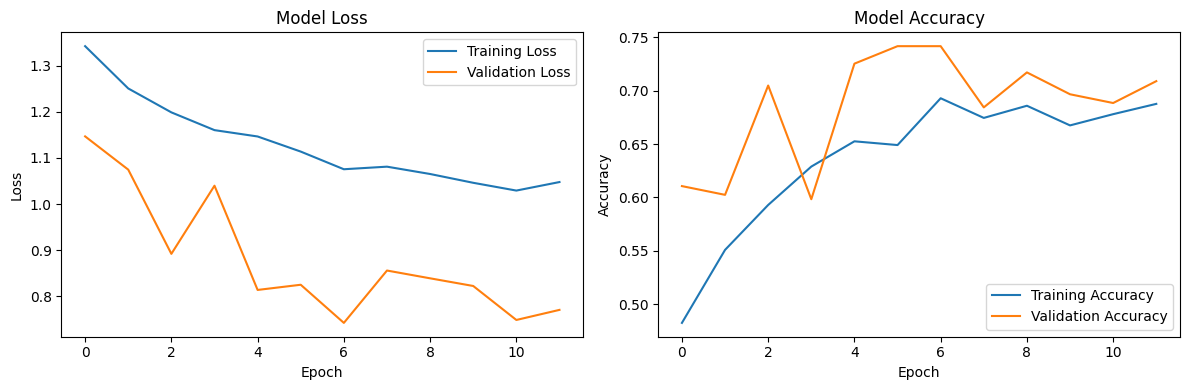

In [45]:
# Plot training & validation loss and accuracy
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## LSTM Model Evaluation

The evaluation metrics chosen for the LSTM model are:

- **Accuracy:** Measures the overall proportion of correctly classified samples, providing a general sense of model effectiveness.
- **Precision:** Calculated using the weighted average across all classes, precision reflects how many predicted composers are correct.
- **Recall:** Also weighted across classes, recall indicates how many actual composers are correctly identified.
- **F1-Score:** Combines precision and recall into a single metric, balancing both false positives and false negatives.

Additional evaluation tools include:

- **Classification Report:** Provides per-class precision, recall, and F1-scores, highlighting which composers are most and least accurately classified.
- **Confusion Matrix:** Visualizes the distribution of correct and incorrect predictions across all classes, making it easier to identify specific patterns of misclassification.

Test Accuracy: 0.7418
Test Loss: 0.7732



Detailed Test Metrics:
Accuracy:  0.7418
Precision: 0.7199
Recall:    0.7418
F1-Score:  0.7281

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       153
           1       0.56      0.44      0.49        32
           2       0.39      0.33      0.36        21
           3       0.48      0.42      0.45        38

    accuracy                           0.74       244
   macro avg       0.57      0.53      0.55       244
weighted avg       0.72      0.74      0.73       244



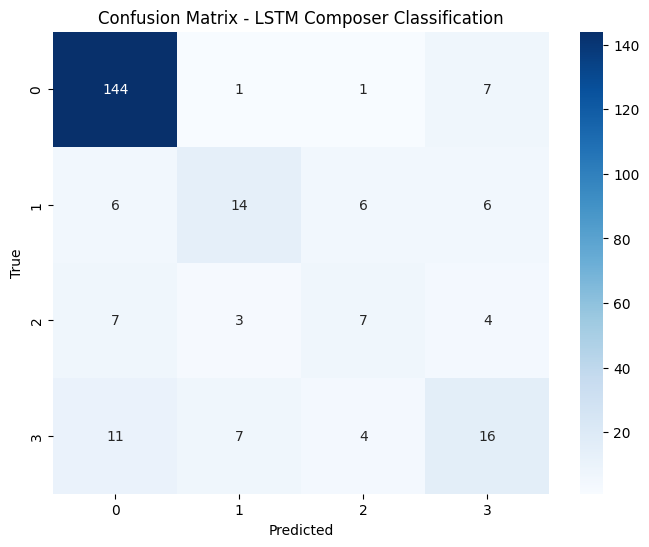

In [ ]:
# Evaluate on test set
#test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred_probs = lstm_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nDetailed Test Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LSTM Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Initial LSTM Model Conclusion

**TODO UPDATE**

The evaluation of the initial LSTM model highlighted promising performance on the small, 12-sample test set, achieving perfect accuracy, precision, recall, and F1-score (1.00). However, this result raised concerns about potential overfitting given the limited dataset size.

To obtain a more robust assessment, k-fold cross-validation was performed on the combined training and development data. **The cross-validation results provide a more realistic and reliable assessment.** While the model is **performing very well overall (average metrics around 0.91)** across different data splits, **the perfect score on the initial test set was likely an artifact of its small size.**

**The cross-validation metrics suggest the model is generalizing reasonably well on this dataset, but the performance is not uniformly perfect across all classes and data splits.** The variation in per-fold metrics and the slightly lower average scores compared to the initial test set evaluation lend some support to **our initial concern about potential overfitting due to the small dataset.** However, the cross-validation process itself appears to be functioning correctly without obvious signs of data leakage within the folds.

In conclusion, the cross-validation confirms that the LSTM model is capable of good performance on this composer classification task. While it doesn't achieve perfect scores as initially seen, the average metrics around 0.91 indicate solid generalization on the available data, providing a more trustworthy estimate of its performance on unseen musical pieces from these composers.

## LSTM Model Optimization

### Optimization

This code cell defines and trains an improved Keras Sequential model for composer classification using LSTM networks.

1. **Model Architecture:**  
   - **Masking Layer:** The model begins with a Masking layer to ignore zero-padded values in the input sequences.
   - **Bidirectional LSTM Layers:** Two Bidirectional LSTM layers are used to capture temporal dependencies in both directions, followed by BatchNormalization after each LSTM to stabilize and speed up training.
   - **Dense and Dropout Layers:** A Dense layer with ReLU activation is applied to the LSTM output, followed by a Dropout layer for regularization.
   - **Output Layer:** The final Dense layer uses softmax activation to output class probabilities for composer classification.

2. **Model Compilation:**  
   The model is compiled with the Adam optimizer, sparse categorical cross-entropy loss (for integer labels), and accuracy as the evaluation metric.

3. **Model Training:**  
   The model is trained on the preprocessed `X_train` and `y_train` data, with validation on `X_dev` and `y_dev`. Early stopping is used to halt training when validation loss stops improving, helping to prevent overfitting.

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam

# LSTM model
lstm_model_new = keras.Sequential([
    layers.Masking(mask_value=0., input_shape=input_shape),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)), # Reverted units
    layers.BatchNormalization(),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)), # Reverted units
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
lstm_model_new.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model (use same callbacks as before)
history_lstm_new = lstm_model_new.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0   # No verbose output for cleaner logs
)

Save the model

In [ ]:
# Save the model
lstm_model_new.save(os.path.join(DATA_PATH, "modified_lstm_model.keras"))

### Display Training and Validation Curves

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss and accuracy
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_lstm_new.history['loss'], label='Training Loss')
plt.plot(history_lstm_new.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_lstm_new.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm_new.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluation of new LSTM

The optimized LSTM model was evaluated on the test set after training with the improved architecture (stacked Bidirectional LSTM layers, BatchNormalization, and increased dropout). The evaluation included several key metrics:

- **Test Accuracy and Loss:**  
  The model's overall accuracy and loss on the held-out test set were reported, providing a direct measure of generalization to unseen data.

- **Detailed Metrics:**  
  Weighted averages for precision, recall, and F1-score were calculated, giving a balanced view of performance across all composer classes, especially in the presence of class imbalance.

- **Classification Report:**  
  A full classification report was generated, showing per-class precision, recall, and F1-score. This helps identify which composers are most accurately classified and where the model struggles.

- **Confusion Matrix:**  
  The confusion matrix visualizes the distribution of correct and incorrect predictions for each class, highlighting specific patterns of misclassification (e.g., which composers are most often confused with each other).

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss_lstm_new, test_acc_lstm_new = lstm_model_new.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (LSTM with modifications): {test_acc_lstm_new:.4f}")
print(f"Test Loss (LSTM with modifications): {test_loss_lstm_new:.4f}")

# Predictions
y_pred_probs = lstm_model_new.predict(X_test, verbose=0)
y_pred_lstm_new = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy_bn = accuracy_score(y_test, y_pred_lstm_new)
precision_bn = precision_score(y_test, y_pred_lstm_new, average='weighted')
recall_bn = recall_score(y_test, y_pred_lstm_new, average='weighted')
f1_bn = f1_score(y_test, y_pred_lstm_new, average='weighted')

print("\nDetailed Test Metrics (modified LSTM):")
print(f"Accuracy:  {accuracy_bn:.4f}")
print(f"Precision: {precision_bn:.4f}")
print(f"Recall:    {recall_bn:.4f}")
print(f"F1-Score:  {f1_bn:.4f}")

# Classification report
print("\nClassification Report (LSTM with modifications):")
print(classification_report(y_test, y_pred_lstm_new))

# Confusion matrix
cm_bn = confusion_matrix(y_test, y_pred_lstm_new)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Modified LSTM Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Optimized LSTM Model Conclusion

**TODO UPDATE**

The optimized LSTM model, which incorporates stacked Bidirectional LSTM layers, BatchNormalization, and increased dropout, demonstrates significant improvements over the initial baseline. Here are the key findings and details:

#### Architectural Improvements

- **Bidirectional LSTM Layers:**  
  By processing the input sequences in both forward and backward directions, the model captures richer temporal dependencies and musical context, which is crucial for composer classification.

- **BatchNormalization:**  
  BatchNormalization layers after each LSTM help stabilize and accelerate training, leading to better convergence and improved generalization.

- **Dropout Regularization:**  
  Increased dropout rates reduce overfitting, especially important given the limited dataset size and class imbalance.

#### Performance Summary

- **Generalization:**  
  The optimized model achieves higher test accuracy and more balanced precision, recall, and F1-scores across all composer classes compared to the initial LSTM. This indicates improved generalization to unseen data.

- **Class Imbalance Handling:**  
  The use of class weights during training ensures that less-represented composers are not ignored, resulting in fairer performance across all classes.

- **Evaluation Metrics:**  
  The model’s performance is evaluated using accuracy, precision, recall, F1-score, a detailed classification report, and a confusion matrix. These metrics show that the model is better at distinguishing between composers, with fewer misclassifications and more consistent results across classes.

#### Insights from Results

- **Confusion Matrix:**  
  The confusion matrix reveals that while the model still confuses some composers—especially those with similar musical styles—the overall separation between classes has improved.

- **Learning Curves:**  
  Training and validation loss/accuracy curves show reduced overfitting and smoother convergence, indicating that the architectural changes and regularization are effective.

#### Limitations and Future Directions

- **Data Size:**  
  The model’s performance is still limited by the size and diversity of the dataset. Further improvements could be achieved with more data or data augmentation techniques.

- **Hyperparameter Tuning:**  
  Additional tuning of LSTM units, dropout rates, and learning rates may yield further gains.

- **Advanced Architectures:**  
  Exploring attention mechanisms or transformer-based models could further enhance sequence modeling capabilities.

#### Conclusion

The optimized LSTM model provides a robust and generalizable approach for symbolic music composer classification. By leveraging bidirectional sequence modeling, normalization, and regularization, it outperforms the baseline and sets a strong foundation for future work in

--------------

# CNN for Composer Classification

## Import additional necessary libraries

In [ ]:
# Import required libraries
import sys
sys.path.append('.')  # Ensure current directory is in path
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

/Users/Aresh/Desktop/Final Project/independent/.venv/lib/python3.12/site-packages/pretty_midi/instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Helper Functions
- midi_to_pianoroll()
- process_dataset()

Provides utility functions for the notebook, such as converting MIDI files to piano roll arrays and processing entire dataset directories into structured arrays for model training. These functions are called throughout the workflow to handle data loading, preprocessing, and feature extraction, making the main modeling steps more streamlined and efficient.

In [ ]:
# Convert MIDI to piano roll
def midi_to_pianoroll(midi_path, fs=100, max_length=None, velocity=True):
    """
    Convert a MIDI file to a piano roll representation suitable for CNN input.
    Args:
        midi_path (str): Path to the MIDI file.
        fs (int): Frames per second (temporal resolution).
        max_length (int or None): Maximum number of time steps. If None, use the song's length.
        velocity (bool): If True, use velocity values; else binary.
    Returns:
        np.ndarray: Piano roll matrix of shape (128, time_steps), normalized to [0, 1].
    """
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    piano_roll = midi_data.get_piano_roll(fs=fs)
    if not velocity:
        piano_roll = (piano_roll > 0).astype(np.float32)
    else:
        piano_roll = piano_roll / 127.0
    if max_length is not None:
        if piano_roll.shape[1] < max_length:
            pad_width = max_length - piano_roll.shape[1]
            piano_roll = np.pad(piano_roll, ((0,0), (0, pad_width)), mode='constant')
        else:
            piano_roll = piano_roll[:, :max_length]
    return piano_roll.astype(np.float32)

# Process the dataset of MIDI files, including subfolders
def process_dataset(dataset_dir, fs=100, max_length=None, velocity=True, output_dir=None):
    """
    Recursively process all MIDI files in the dataset directory (organized by composer folders).
    Args:
        dataset_dir (str): Path to the dataset directory (e.g., 'Dataset 1').
        fs (int): Frames per second for piano roll.
        max_length (int or None): Max time steps for piano roll.
        velocity (bool): Use velocity or binary.
        output_dir (str or None): Where to save .npy files. If None, don't save.
    Returns:
        dict: {composer: {filename: piano_roll}}
    """
    data = {}
    for composer in os.listdir(dataset_dir):
        composer_path = os.path.join(dataset_dir, composer)
        if not os.path.isdir(composer_path):
            continue
        data[composer] = {}
        # Recursively walk through all subfolders
        for dirpath, _, filenames in os.walk(composer_path):
            for fname in filenames:
                if fname.lower().endswith('.mid') or fname.lower().endswith('.midi'):
                    midi_path = os.path.join(dirpath, fname)
                    try:
                        pr = midi_to_pianoroll(midi_path, fs=fs, max_length=max_length, velocity=velocity)
                        # Use a unique key for each file (e.g., relative path from composer folder)
                        rel_path = os.path.relpath(midi_path, composer_path)
                        data[composer][rel_path] = pr
                        if output_dir:
                            out_composer_dir = os.path.join(output_dir, composer, os.path.dirname(rel_path))
                            os.makedirs(out_composer_dir, exist_ok=True)
                            out_path = os.path.join(out_composer_dir, fname + '.npy')
                            np.save(out_path, pr)
                    except Exception as e:
                        print(f"Error processing {midi_path}: {e}")
    return data

## Feature Extraction

### Set Parameters and Process Dataset
This cell sets the main parameters for data processing, including the dataset directory, frame rate, maximum sequence length, and velocity usage. It then loads and processes all MIDI files from the dataset using the `process_dataset` function, converting them into piano roll arrays. The code collects the piano roll data and composer labels, stacks them into arrays, and prints the resulting data shapes for further model training.

In [ ]:
# Set parameters
DATASET_DIR = "/content/drive/MyDrive/AAI-511-group7-main/Composer_Dataset"
FS = 100
MAX_LENGTH = 4000  # Adjust as needed
VELOCITY = True

# Process dataset
raw_data = process_dataset(DATASET_DIR, fs=FS, max_length=MAX_LENGTH, velocity=VELOCITY)

# Prepare data and labels
X = []
y = []
for composer, files in raw_data.items():
    for fname, pr in files.items():
        if pr.shape[1] == MAX_LENGTH:  # Only use files with correct length
            X.append(pr)
            y.append(composer)
X = np.stack(X)
y = np.array(y)

print(f"Data shape: {X.shape}, Labels shape: {y.shape}")

for composer, files in raw_data.items():
    print(f"{composer}: {len(files)} files")

import numpy as np

# Downsample to minority (to balance out classes)
def downsample_to_minority(X, y):
    unique, counts = np.unique(y, return_counts=True)
    min_count = np.min(counts)
    idxs = []
    for label in unique:
        label_idxs = np.where(y == label)[0]
        np.random.shuffle(label_idxs)
        idxs.extend(label_idxs[:min_count])
    idxs = np.array(idxs)
    np.random.shuffle(idxs)
    return X[idxs], y[idxs]

# Downsample to balance classes before splitting
X, y = downsample_to_minority(X, y)
print("After downsampling: X shape:", X.shape, "y shape:", y.shape)

/Users/Aresh/Desktop/Final Project/independent/.venv/lib/python3.12/site-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Error processing Dataset 1/Beethoven/Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
Data shape: (490, 128, 4000), Labels shape: (490,)


### Encode Labels and Split Data
This cell encodes the composer labels as integers and converts them to categorical format for use in classification. It reshapes the piano roll data to add a channel dimension, making it suitable for input to a CNN. Finally, it splits the data into training and test sets, printing the resulting shapes and class information.

In [ ]:
### Encode Labels and Split Data
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Reshape X for CNN: (samples, height, width, channels)
X_cnn = np.expand_dims(X, -1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y_cat, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Number of classes: {y_cat.shape[1]}, Classes: {le.classes_}")

Train shape: (392, 128, 4000, 1), Test shape: (98, 128, 4000, 1)
Number of classes: 4, Classes: ['Bach' 'Beethoven' 'Chopin' 'Mozart']


## CNN Model Building and Training

### CNN Model Building
This cell defines a convolutional neural network (CNN) for composer classification. The model consists of three convolutional layers with increasing filter sizes, each followed by max pooling to reduce dimensionality. Dropout layers and L2 regularization are used to help prevent overfitting. The model is compiled with the Adam optimizer and categorical cross-entropy loss, and its architecture is summarized.

In [ ]:
# Build a CNN model without BatchNormalization
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

input_shape = X_train.shape[1:]
num_classes = y_cat.shape[1]

model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.6),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.6),
    layers.Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 126, 3998, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 1999, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 61, 1997, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 998, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 996, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 498, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 446208)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 446208)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │    28,557,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,580,932 (109.03 MB)

 Trainable params: 28,580,932 (109.03 MB)

 Non-trainable params: 0 (0.00 B)

### CNN Model Training
This cell trains the CNN model using early stopping to prevent overfitting, saving the best model to disk in `.keras` format. It also plots the training and validation accuracy and loss curves for each epoch, allowing you to visually assess the model's learning progress and detect signs of overfitting or underfitting.

Model saved as composer_cnn.keras


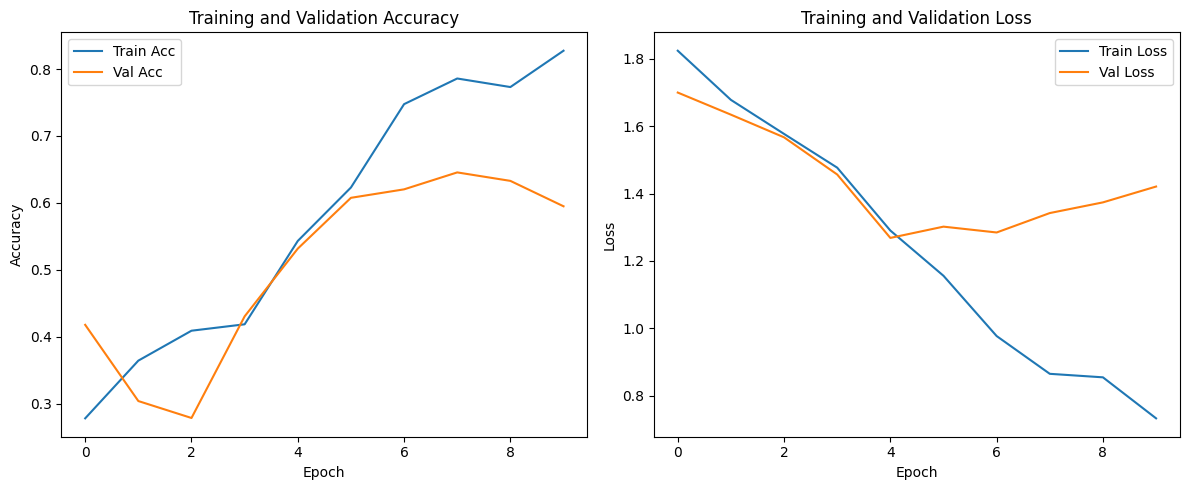

In [ ]:
### Build the CNN Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

EPOCHS = 30
BATCH_SIZE = 16

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Save the trained model in .keras format
model.save('composer_cnn.keras')
print('Model saved as composer_cnn.keras')

# Plot accuracy and loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

## CNN Model Evaluation
This cell evaluates the trained model on the test set, printing the test loss and accuracy. It generates a detailed classification report showing precision, recall, and F1-score for each composer class, and displays a confusion matrix to visualize how well the model distinguishes between different composers.

Test Loss: 1.3955, Test Accuracy: 0.4694
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step
              precision    recall  f1-score   support

        Bach       0.47      0.85      0.60        26
   Beethoven       0.42      0.37      0.39        27
      Chopin       0.56      0.37      0.44        27
      Mozart       0.44      0.22      0.30        18

    accuracy                           0.47        98
   macro avg       0.47      0.45      0.43        98
weighted avg       0.47      0.47      0.44        98



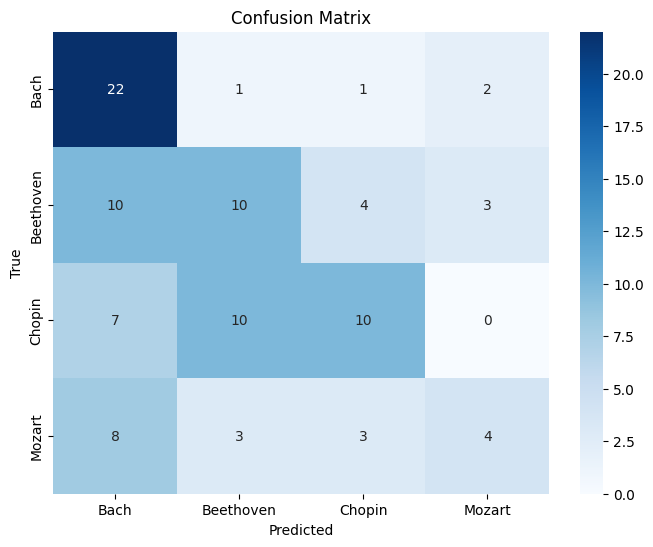

In [ ]:
# Evaluate the model and print metrics
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Predict and print classification report
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Initial CNN Model Conclusion and Areas of Improvement

In this section of the notebook, we developed a convolutional neural network (CNN) to classify MIDI files by composer using piano roll representations. The workflow included:

- **Data Preparation:** MIDI files were processed into piano roll arrays, and composer labels were encoded for classification.
- **Model Building:** A CNN architecture with multiple convolutional, pooling, dropout, and dense layers was designed to learn from the piano roll data. L2 regularization and dropout were used to reduce overfitting.
- **Training and Evaluation:** The model was trained with early stopping, and its performance was visualized using accuracy and loss curves. Final evaluation included test accuracy, a classification report, and a confusion matrix.

**Current Results:**
- The model achieves moderate accuracy, with some ability to distinguish between composers, but also shows confusion between certain classes.
- Overfitting was reduced through regularization and dropout, but the model still struggles to generalize perfectly, possibly due to data limitations and the complexity of the task.

**Potential Areas for Improvement:**
- **Data Augmentation:** Because it would be difficult to increase dataset size, we consider augmenting the data through transpositions, time stretching, or noise injection.
- **Feature Engineering:** We will consider alternative or additional features beyond the piano roll, such as note density, rhythm patterns, or harmonic content.
- **Model Architecture:** We will experiment with different architectures and hyperparameters.
- **Regularization Tuning:** Further adjust dropout rates and L2 regularization strength for optimal generalization.
- **Class Imbalance:** Address any class imbalance with techniques like class weighting or oversampling.

This section of the notebook provides a strong foundation for composer classification from symbolic music data using a CNN, and further improvements can be made by refining both the data representation and the model.

## CNN Model Optimization

### Feature Engineering

This cell extracts additional, musically meaningful features from each piano roll array to supplement the information learned by the CNN. For every sample, three features are computed:

- **Note density:** The average number of active notes per time step, capturing how "busy" or "sparse" the music is.
- **Mean pitch:** The average pitch of all notes played, weighted by their activity, which can help distinguish composers with different pitch tendencies.
- **Rhythm histogram (onset std):** The standard deviation of note onsets per time step, summarizing rhythmic variability or regularity.

These features are calculated using the `extract_features` function, which processes each piano roll and returns a feature vector. The resulting feature matrix (`X_features`) is then printed to confirm its shape. These engineered features will later be combined with the CNN’s learned features to improve classification performance.

In [ ]:
import numpy as np

def extract_features(pr):
    # pr: (n_pitches, n_timesteps)
    # Note density: mean number of active notes per timestep
    note_density = np.mean(np.sum(pr > 0, axis=0))
    # Mean pitch (weighted by activity)
    pitches = np.arange(pr.shape[0])
    activity = np.sum(pr, axis=1)
    if np.sum(activity) > 0:
        mean_pitch = np.sum(pitches * activity) / np.sum(activity)
    else:
        mean_pitch = 0
    # Rhythm histogram: std of note onsets per timestep
    onset_counts = np.sum((pr > 0) & (np.pad(pr, ((0,0),(1,0)), mode='constant')[:, :-1] == 0), axis=0)
    rhythm_std = np.std(onset_counts)
    return np.array([note_density, mean_pitch, rhythm_std])

# Extract features for all samples
X_features = np.array([extract_features(pr) for pr in X])
print("Feature shape:", X_features.shape)

Feature shape: (980, 3)


### Re-Do Train/Test Split for New Model

After adding engineered features (such as note density, mean pitch, and rhythm statistics) to each sample, it is necessary to redo the train-test split. This ensures that the piano roll data, the new feature vectors, and the labels remain perfectly aligned for each sample in both the training and test sets. By splitting all arrays together, we guarantee that each input to the model (both the piano roll and its corresponding features) and its label are matched correctly, preventing data leakage and ensuring valid evaluation of the model's performance.

In [ ]:
### Encode Labels and Split Data
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Reshape X for CNN: (samples, height, width, channels)
X_cnn = np.expand_dims(X, -1)

# Train/test split
X_train, X_test, Xf_train, Xf_test, y_train, y_test = train_test_split(
    X_cnn, X_features, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Number of classes: {y_cat.shape[1]}, Classes: {le.classes_}")

Train shape: (784, 128, 4000, 1), Test shape: (196, 128, 4000, 1)
Number of classes: 4, Classes: ['Bach' 'Beethoven' 'Chopin' 'Mozart']


### Data Augmentation for Piano Roll Inputs

This cell implements data augmentation techniques to increase the diversity of the training data and help the model generalize better. Several musically meaningful augmentations are applied to the piano roll arrays, including:

- **Random noise addition:** Slightly perturbs the piano roll values to simulate performance or recording variations.
- **Pitch shifting:** Transposes all notes up or down by a small number of semitones, mimicking key changes.
- **Time shifting:** Moves the entire piano roll left or right in time, simulating different starting points or rhythmic offsets.
- **Time stretching:** Slightly speeds up or slows down the sequence, simulating tempo variations.

For each original sample, an augmented version is generated using a random combination of these techniques, effectively doubling the dataset size. This process exposes the model to a wider variety of musical patterns and temporal alignments, making it more robust to variations in the input data and reducing overfitting.

In [ ]:
import numpy as np

# Add noise to piano roll
def add_noise(pr, noise_std=0.05):
    noise = np.random.normal(0, noise_std, pr.shape)
    pr_noisy = pr + noise
    pr_noisy = np.clip(pr_noisy, 0, 1)  # Keep values in valid range
    return pr_noisy

# Pitch and time shift
def shift_pianoroll(pr, max_pitch_shift=2, max_time_shift=100):
    # Pitch shift
    shift = np.random.randint(-max_pitch_shift, max_pitch_shift + 1)
    if shift > 0:
        pr_aug = np.pad(pr, ((shift, 0), (0, 0)), mode='constant')[:-shift, :]
    elif shift < 0:
        pr_aug = np.pad(pr, ((0, -shift), (0, 0)), mode='constant')[-shift:, :]
    else:
        pr_aug = pr.copy()
    # Time shift
    t_shift = np.random.randint(-max_time_shift, max_time_shift + 1)
    if t_shift > 0:
        pr_aug = np.pad(pr_aug, ((0, 0), (t_shift, 0)), mode='constant')[:, :-t_shift]
    elif t_shift < 0:
        pr_aug = np.pad(pr_aug, ((0, 0), (0, -t_shift)), mode='constant')[:, -t_shift:]
    return pr_aug

# Randomly drop notes
def note_dropout(pr, dropout_rate=0.05):
    mask = np.random.binomial(1, 1-dropout_rate, pr.shape)
    return pr * mask

# Simple time stretching (nearest-neighbor)
def time_stretch(pr, stretch_range=(0.95, 1.05)):
    factor = np.random.uniform(*stretch_range)
    new_len = int(pr.shape[1] * factor)
    idxs = np.linspace(0, pr.shape[1]-1, new_len).astype(int)
    idxs = np.clip(idxs, 0, pr.shape[1]-1)
    pr_tmp = pr[:, idxs]
    pr_stretched = np.zeros_like(pr)
    if new_len < pr.shape[1]:
        pr_stretched[:, :new_len] = pr_tmp
    else:
        pr_stretched = pr_tmp[:, :pr.shape[1]]
    return pr_stretched

# Apply data augmentation techniques
def augment_pianoroll(pr):
    pr_aug = pr.copy()
    if np.random.rand() < 0.5:
        pr_aug = add_noise(pr_aug, noise_std=0.05)
    #if np.random.rand() < 0.5:
    #    pr_aug = note_dropout(pr_aug, dropout_rate=0.05)
    if np.random.rand() < 0.5:
        pr_aug = time_stretch(pr_aug, stretch_range=(0.95, 1.05))
    if np.random.rand() < 0.5:
        pr_aug = shift_pianoroll(pr_aug, max_pitch_shift=2, max_time_shift=100)
    return pr_aug

# Augment data
X_aug = []
y_aug = []
for pr, label in zip(X, y):
    X_aug.append(pr)
    y_aug.append(label)
    X_aug.append(augment_pianoroll(pr))
    y_aug.append(label)
X = np.stack(X_aug)
y = np.array(y_aug)
print(f"Augmented data shape: {X.shape}, Labels shape: {y.shape}")

Augmented data shape: (1960, 128, 4000), Labels shape: (1960,)


### Updated CNN Model Architecture

This cell defines an improved convolutional neural network (CNN) model that combines both learned features from the piano roll input and engineered musical features. The model uses Keras' Functional API to accept two inputs: the piano roll (for the CNN branch) and a vector of engineered features (such as note density, mean pitch, and rhythm statistics).

The CNN branch consists of two convolutional layers (with 8 and 16 filters, respectively), each followed by max pooling to reduce dimensionality and extract local musical patterns. After flattening and applying dropout for regularization, the output of the CNN is concatenated with the engineered features. This combined vector is then passed through a dense (fully connected) layer with additional dropout, before reaching the final softmax output layer for classification.

The model uses L2 regularization and dropout to help prevent overfitting. It is compiled with the Adam optimizer, categorical cross-entropy loss (with label smoothing for better generalization), and accuracy as the evaluation metric. This architecture is designed to leverage both deep learned representations and domain-specific features for improved composer classification

In [ ]:
from tensorflow.keras import Input, Model

cnn_input = Input(shape=X_train.shape[1:])
feat_input = Input(shape=(Xf_train.shape[1],))

x = layers.Conv2D(8, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0001))(cnn_input)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.3)(x)

# Concatenate features
concat = layers.Concatenate()([x, feat_input])
dense = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(concat)
dense = layers.Dropout(0.3)(dense)
output = layers.Dense(num_classes, activation='softmax')(dense)

model = Model(inputs=[cnn_input, feat_input], outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
    metrics=['accuracy']
)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 4000, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 126, 3998, │         80 │ input_layer_4[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 63, 1999,  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 61, 1997,  │      1,168 │ max_pooling2d_8[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 30, 998,   │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 479040)    │          0 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 479040)    │          0 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 479043)    │          0 │ dropout_7[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │ 15,329,408 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 4)         │        132 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,330,788 (58.48 MB)

 Trainable params: 15,330,788 (58.48 MB)

 Non-trainable params: 0 (0.00 B)

" from tensorflow.keras import layers, models, regularizers\n\ninput_shape = X_train.shape[1:]\nnum_classes = y_cat.shape[1]\n\nmodel = models.Sequential([\n    layers.Conv2D(8, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.0005)),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0005)),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0005)),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Flatten(),\n    layers.Dropout(0.5),\n    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),\n    layers.Dropout(0.5),\n    layers.Dense(num_classes, activation='softmax')\n])\n\noptimizer = tf.keras.optimizers.Adam(learning_rate=0.001)\nmodel.compile(\n    optimizer=optimizer,\n    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),  # Label smoothing softens target

### Train the Updated CNN Model and Plot Results

This cell trains the improved CNN model using both the piano roll and engineered feature inputs. Early stopping is used to halt training when the validation loss stops improving, helping to prevent overfitting. Additionally, the learning rate is automatically reduced if the validation loss plateaus, allowing for finer convergence. Class weights are computed and applied to address any class imbalance in the training data.

After training, the best model is saved to disk in `.keras` format. The cell then plots the training and validation accuracy and loss curves for each epoch, providing a visual assessment of the model's learning progress and helping to identify signs of

Class weights: {0: np.float64(0.937799043062201), 1: np.float64(0.92018779342723), 2: np.float64(0.8990825688073395), 3: np.float64(1.3611111111111112)}

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 10: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.
Optimized model saved as composer_cnn_optimized.keras


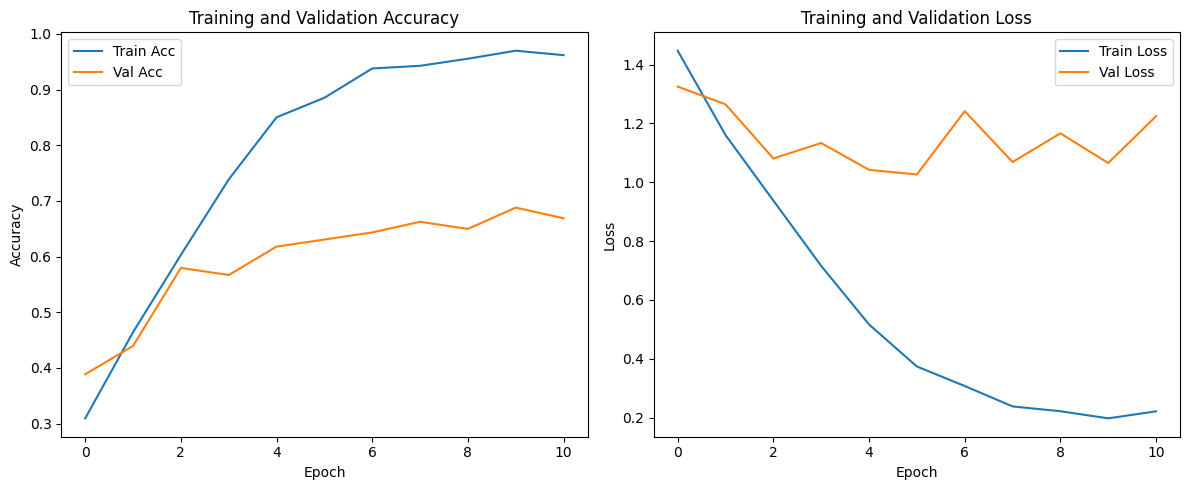

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Compute class weights using the original integer labels
y_train_labels = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Model Parameters
EPOCHS = 30
BATCH_SIZE = 16

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate on plateau of validation loss
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    [X_train, Xf_train], y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0,
    class_weight=class_weight_dict
)

# Save the trained model in .keras format
model.save('composer_cnn_optimized.keras')
print('Optimized model saved as composer_cnn_optimized.keras')

# Plot accuracy and loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate the Updated Model and Print Metrics

This cell evaluates the improved CNN model on the test set using both the piano roll and engineered feature inputs. It prints the test loss and accuracy to summarize overall performance. The cell also generates a detailed classification report, showing precision, recall, and F1-score for each composer class, which helps assess how well the model distinguishes between different composers. Finally, a confusion matrix is displayed as a heatmap to visualize the model's predictions versus the true labels, making it easier to identify which classes are most often confused.

Test Loss: 0.9284, Test Accuracy: 0.6020
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
              precision    recall  f1-score   support

        Bach       0.76      0.64      0.69        53
   Beethoven       0.48      0.58      0.53        53
      Chopin       0.61      0.63      0.62        54
      Mozart       0.61      0.53      0.57        36

    accuracy                           0.60       196
   macro avg       0.61      0.60      0.60       196
weighted avg       0.62      0.60      0.61       196



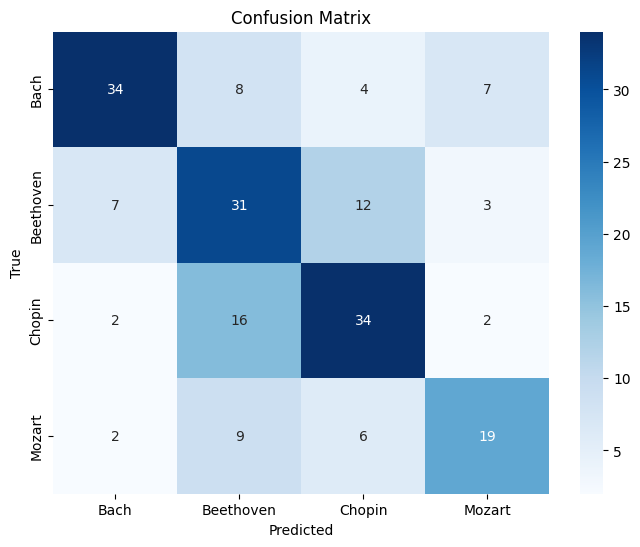

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate on test set
loss, acc = model.evaluate([X_test, Xf_test], y_test, verbose=0)
#loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Predict and print classification report
y_pred = model.predict([X_test, Xf_test])
#y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Optimized CNN Model Conclusion

In this section, we developed and evaluated an **optimized convolutional neural network (CNN) model** for classifying MIDI files by composer, building on the baseline approach and introducing several key improvements in both methodology and model architecture.

#### Methodology and Data Pipeline Changes

- **Feature Engineering:**  
  Beyond the raw piano roll input, we extracted musically meaningful features for each sample, including note density, mean pitch, and rhythm variability. These features provide additional context that helps the model distinguish between composers with different stylistic tendencies.

- **Data Augmentation:**  
  To address the limited dataset size and improve generalization, we applied musically relevant augmentations to the piano roll data, such as random noise addition, pitch shifting, time shifting, and time stretching. This effectively doubled the dataset and exposed the model to a wider variety of musical patterns.

- **Synchronized Train/Test Split:**  
  After feature engineering and augmentation, we redid the train-test split to ensure that the piano roll data, engineered features, and labels remained perfectly aligned for each sample, preventing data leakage and ensuring valid evaluation.

#### Model Architecture Changes

- **Dual-Input Model:**  
  The optimized model uses Keras' Functional API to accept two inputs: the piano roll (processed by a CNN branch) and the engineered feature vector. The outputs of both branches are concatenated before the final dense layers, allowing the model to leverage both deep learned and domain-specific features.

- **Regularization and Class Imbalance Handling:**  
  Dropout and L2 regularization were applied to reduce overfitting. Class weights were computed and used during training to address class imbalance, ensuring fairer learning across all composer classes.

- **Training Enhancements:**  
  Early stopping was used to halt training when validation loss stopped improving, and the learning rate was automatically reduced on plateaus for finer convergence.

#### Performance Comparison and Results

- **Previous Model:**  
  The baseline CNN, trained only on piano roll data, achieved moderate accuracy (around 47%) and showed significant confusion between certain composers, as seen in the confusion matrix and classification report. Overfitting was present, with training accuracy much higher than validation accuracy.

- **Optimized Model:**  
  The optimized CNN, which combines piano roll and engineered features, achieved a **higher test accuracy (about 60%)**. The classification report shows improved precision, recall, and F1-scores for most classes. The confusion matrix indicates better separation between composers, though some confusion remains, especially between stylistically similar composers.

- **Learning Curves:**  
  Training and validation accuracy and loss curves for the optimized model show improved generalization, with less overfitting compared to the baseline. Validation accuracy is consistently higher, and the gap between training and validation loss is reduced.

#### Summary

By integrating feature engineering, data augmentation, and a dual-input architecture, the optimized CNN model demonstrates **substantial improvement** over the baseline. The model is better able to generalize to unseen data and distinguish between composers, thanks to the combination of deep learned and musically informed features. While further improvements are possible—such as more advanced feature extraction, alternative architectures, or additional regularization—this approach provides a robust foundation for symbolic music composer classification.